In [120]:
import jax.numpy as jnp 
import matplotlib.pyplot as plt 

import sys 
sys.path.insert(0, "../")

from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_PROCESSES_REGRESSION import GP_REGRESSION as GP 

# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

#### B) GP regression (kernel effects, predictive, evidence)}

Inputs: 
$$
x = [0,\ 0.5,\ 1.0,\ 1.5]^T,\quad y = [0.1,\ 0.7,\ 0.9,\ 0.2]^T
$$

Kernel:
$$
k(x, x') = \sigma_f^2 \exp\left( -\frac{(x - x')^2}{2\ell^2} \right), \quad \text{Use } \sigma_f^2 = 1.0,\ \ell = 0.6,\ \sigma_n^2 = 0.05
$$

1. Form $K$ and $K_y = K + \sigma_n^2 I$

2. Compute posterior mean/variance at $ x_* = \{0.25,\ 0.75,\ 1.25\} $

3. Compute $ \log p(y \mid X, \boldsymbol{\theta})$

4. Halve the kernel scale: use $0.5\,\ell$. Predict again at $ x_* $ and explain the change in mean/variance

5. Is this kernel stationary? Isotropic? Justify.


#### 1) 

In [121]:
x = jnp.array([0, 0.5, 1.0, 1.5]).reshape(-1, 1)
y = jnp.array([0.1, 0.7, 0.9, 0.2]).reshape(-1, 1)

In [122]:
kappa = 1
ell = 0.6 
sigma = 0.05 

kernel = GP.StationaryIsotropicKernel(GP.squared_exponential, kappa=kappa, lengthscale=ell)

In [123]:
prior_K = kernel.contruct_kernel(X1=x, X2=x, kappa=kappa, lengthscale=ell)


prior_K

Array([[1.00000001, 0.70664828, 0.24935221, 0.04393693],
       [0.70664828, 1.00000001, 0.70664828, 0.24935221],
       [0.24935221, 0.70664828, 1.00000001, 0.70664828],
       [0.04393693, 0.24935221, 0.70664828, 1.00000001]], dtype=float64)

In [124]:
marginal_likelihood = prior_K + sigma * jnp.eye(len(x))

In [125]:
marginal_likelihood

Array([[1.05000001, 0.70664828, 0.24935221, 0.04393693],
       [0.70664828, 1.05000001, 0.70664828, 0.24935221],
       [0.24935221, 0.70664828, 1.05000001, 0.70664828],
       [0.04393693, 0.24935221, 0.70664828, 1.05000001]], dtype=float64)

In [91]:
GAUS_PROC = GP.GaussianProcessRegression(X=x, y=y, kernel=kernel, kappa=kappa, lengthscale=ell, sigma=sigma)

#### 2) 

In [92]:
x_star = jnp.array([0.25, 0.75, 1.25]).reshape(-1, 1)

In [93]:
mu_post, S_post = GAUS_PROC.predict_f(x_star)

print(f"Mean:  \n{mu_post}")
print(f"Variance: \n{S_post}")

Mean:  
[[0.37464182]
 [0.92225532]
 [0.60752555]]
Variance: 
[[ 0.00669743 -0.00261693  0.00273165]
 [-0.00261693  0.00449969 -0.00261693]
 [ 0.00273165 -0.00261693  0.00669743]]


```python
Mean:  
[[0.37464182]
 [0.92225532]
 [0.60752555]]
Variance: 
[[ 0.00669743 -0.00261693  0.00273165]
 [-0.00261693  0.00449969 -0.00261693]
 [ 0.00273165 -0.00261693  0.00669743]]
```

#### 3) 

In [94]:
log_evidence = GAUS_PROC.log_marginal_likelihood(kappa=kappa, lengthscale=ell, sigma=sigma)
print(f"Log evidence {log_evidence}")

Log evidence -2.9347172167644597


#### 4) 

In [117]:
kappa = 1
ell = 1
sigma = 0.05 

kernel = GP.StationaryIsotropicKernel(GP.squared_exponential, kappa=kappa, lengthscale=ell)
ker_10 = kernel.contruct_kernel(X1=x, X2=x, lengthscale=ell, kappa=kappa)


kappa = 1
ell = 0.6 
sigma = 0.05 

kernel = GP.StationaryIsotropicKernel(GP.squared_exponential, kappa=kappa, lengthscale=ell)
ker_06 = kernel.contruct_kernel(X1=x, X2=x, lengthscale=ell, kappa=kappa)

kappa = 1
ell = 0.5 * 0.6 
sigma = 0.05 
kernel_ = GP.StationaryIsotropicKernel(GP.squared_exponential, kappa=kappa, lengthscale=ell)
ker_03 = kernel_.contruct_kernel(X1=x, X2=x, kappa=kappa, lengthscale=ell)

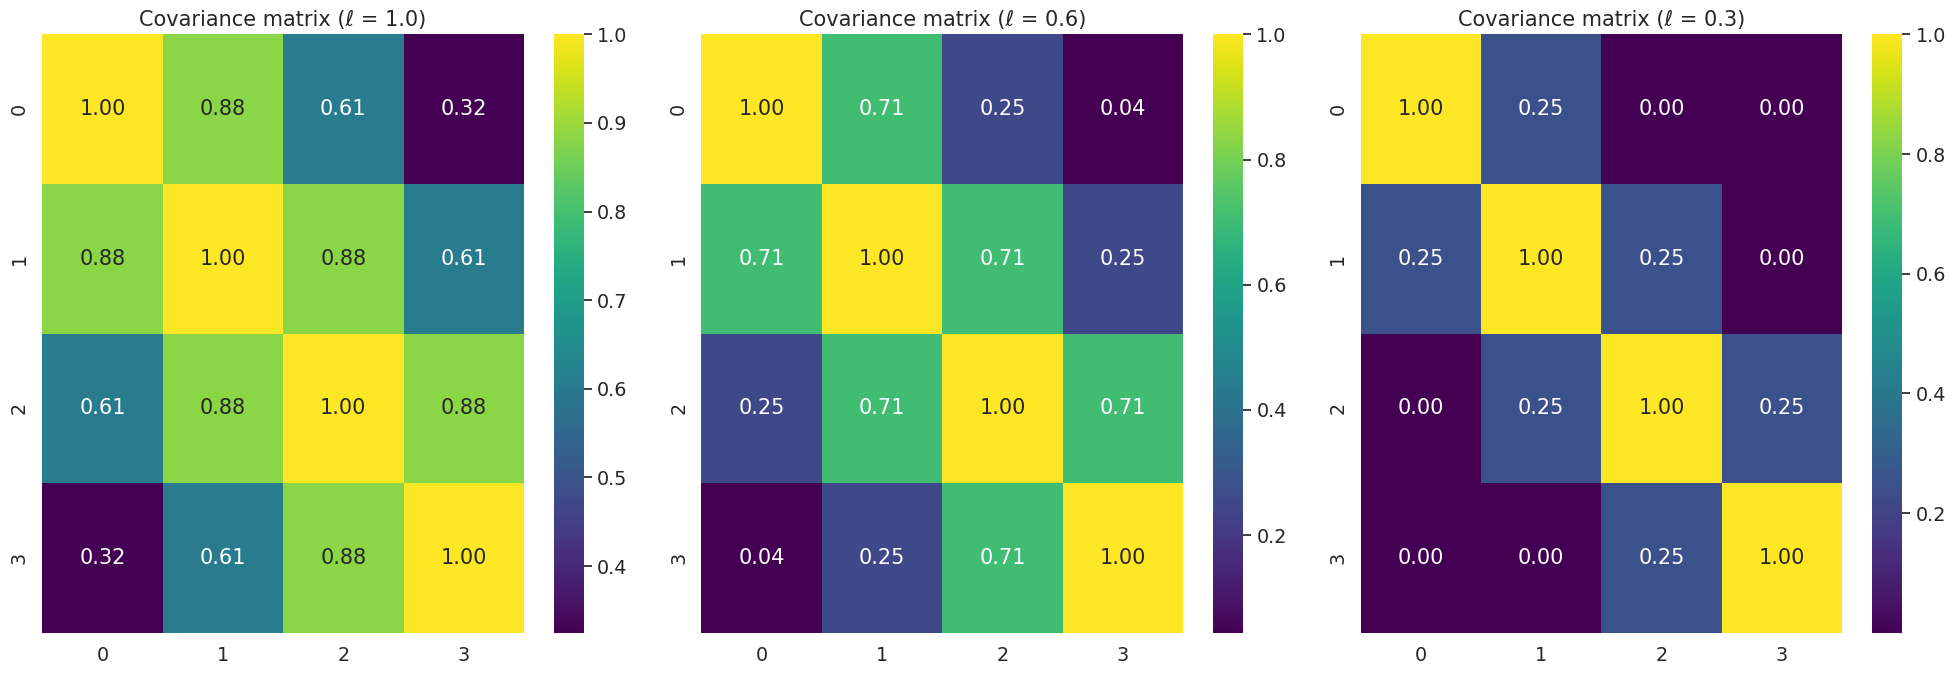

In [119]:
import seaborn as sns

# Create the figure and two subplots
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

sns.heatmap(ker_10, annot=True, fmt=".2f", cmap="viridis", cbar=True, ax=axs[0])
axs[0].set_title('Covariance matrix (ℓ = 1.0)')

# Subfigure 1: heatmap
sns.heatmap(ker_06, annot=True, fmt=".2f", cmap="viridis", cbar=True, ax=axs[1])
axs[1].set_title('Covariance matrix (ℓ = 0.6)')

sns.heatmap(ker_03, annot=True, fmt=".2f", cmap="viridis", cbar=True, ax=axs[2])
axs[2].set_title('Covariance matrix (ℓ = 0.3)')

# Layout and show
plt.tight_layout()
plt.show()
